<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Nulls
=====
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0

C:\Users\Admin\AppData\Local\Temp\ipykernel_28788\4236483022.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(df.columns)


KeyError: 0

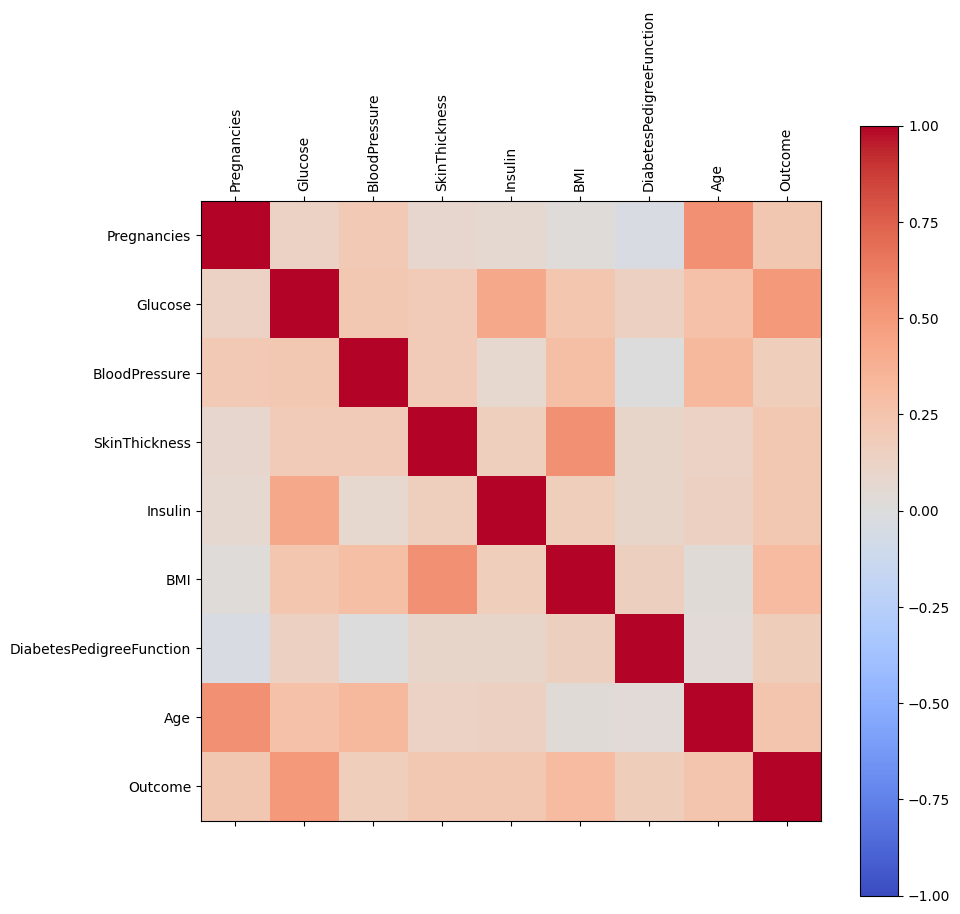

In [1]:
#Loading the data: 1
#1
import numpy as np
import pandas as pd

df = pd.read_csv("diabetes.csv")
df.info()


#Cleaning the data: 2,3,4
#2
# --- check for null values ---
print("Nulls")
print("=====")
print(df.isnull().sum())

#3
# --- check for 0s ---
print("0s")
print("==")
print(df.eq(0).sum())

#4
df[['Glucose','BloodPressure','SkinThickness',
    'Insulin','BMI','DiabetesPedigreeFunction','Age']] = \
df[['Glucose','BloodPressure','SkinThickness',
    'Insulin','BMI','DiabetesPedigreeFunction','Age']].replace(0, np.nan)
df.fillna(df.mean(), inplace=True)   # replace NaN with the mean
print(df.eq(0).sum())


#Examining the Correlation Between the Features: 5
#5
corr = df.corr()
print(corr)


#Plotting the Correlation Between Features: 6, 7, 8
#6
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
cax     = ax.matshow(corr,cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = np.arange(0,len(df.columns),1)
ax.set_xticks(ticks)
ax.set_xticklabels(df.columns)
plt.xticks(rotation = 90)
ax.set_yticklabels(df.columns)
ax.set_yticks(ticks)
#---print the correlation factor--
for i in range(df.shape[1]):
    for j in range(9):
        text = ax.text(j, i, round(corr.iloc[i][j],2),
                       ha="center", va="center", color="w") 
plt.show()

#7
import seaborn as sns
sns.heatmap(df.corr(),annot=True)
#---get a reference to the current figure and set its size--
fig = plt.gcf()
fig.set_size_inches(8,8)

#8
#---get the top four features that has the highest correlation--
print(df.corr().nlargest(4, 'Outcome').index)
#---print the top 4 correlation values--
print(df.corr().nlargest(4, 'Outcome').values[:,8])


#Evaluating the Algorithms: 9,10,11,12, 13
#9
from sklearn import linear_model
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

#---features--
X = df[['Glucose','BMI','Age']]
#---label--
y = df.iloc[:,8]
log_regress = linear_model.LogisticRegression()
log_regress_score = cross_val_score(log_regress, X, y, cv=10, 
scoring='accuracy').mean()
print(log_regress_score)

#10
result = []
result.append(log_regress_score)

#11
from sklearn.neighbors import KNeighborsClassifier
#---empty list that will hold cv (cross-validates) scores--
cv_scores = []
#---number of folds--
folds = 10
#---creating odd list of K for KNN--
ks = list(range(1,int(len(X) * ((folds - 1)/folds)), 2))
#---perform k-fold cross validation--
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X, y, cv=folds, scoring='accuracy').mean()
    cv_scores.append(score)
#---get the maximum score--
knn_score = max(cv_scores)
#---find the optimal k that gives the highest score--
optimal_k = ks[cv_scores.index(knn_score)]
print(f"The optimal number of neighbors is {optimal_k}")
print(knn_score)
result.append(knn_score)

#12
from sklearn import svm
linear_svm = svm.SVC(kernel='linear')
linear_svm_score = cross_val_score(linear_svm, X, y,
                                   cv=10, scoring='accuracy').mean()
print(linear_svm_score)
result.append(linear_svm_score)

#13
rbf = svm.SVC(kernel='rbf')
rbf_score = cross_val_score(rbf, X, y, cv=10, scoring='accuracy').mean()
print(rbf_score)
result.append(rbf_score)


#Selecting the Best Performing Algorithm: 14
#14
algorithms = ["Logistic Regression", "K Nearest Neighbors", "SVM Linear Kernel", "SVM RBF Kernel"]
cv_mean = pd.DataFrame(result,index = algorithms)
cv_mean.columns=["Accuracy"]
cv_mean.sort_values(by="Accuracy",ascending=False)


#Training and Saving the Model: 15
#15
knn = KNeighborsClassifier(n_neighbors=19)
knn.fit(X, y)

#16
import pickle
filename = "diabetes.sav"
pickle.dump(knn, open(filename, "wb"))

#17
#---load the model from disk--
loaded_model = pickle.load(open(filename, 'rb'))
Glucose = 65
BMI = 70
Age = 50
prediction = loaded_model.predict([[Glucose, BMI, Age]])
print(prediction)
if (prediction[0]==0):
    print("Non-diabetic")
else:
    print("Diabetic")

proba = loaded_model.predict_proba([[Glucose, BMI, Age]])
print(proba)
print("Confidence: " + str(round(np.amax(proba[0]) * 100 ,2)) + "%")

#18 - Histogram Distribution
import matplotlib.pyplot as plt
df.hist(
    figsize=(14,10),
    bins=20,
    color='steelblue',
    edgecolor='black'
)
plt.suptitle("Histogram Distribution of Diabetes Features", fontsize=16)
plt.tight_layout()
plt.show()

#19 - Box Plot for Outlier Detection
plt.figure(figsize=(14,6))
df.boxplot(
    patch_artist=True,
    boxprops=dict(facecolor='lightcoral')
)
plt.title("Box Plot – Outlier Detection in Diabetes Dataset", fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

#20 - Correlation Bar Plot with Outcome (Alternative to Heatmap)
import matplotlib.pyplot as plt
corr_with_outcome = df.corr()["Outcome"].drop("Outcome")
plt.figure(figsize=(8,5))
corr_with_outcome.sort_values(ascending=False).plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)
plt.title("Correlation of Features with Outcome", fontsize=14)
plt.ylabel("Correlation Value")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()



# Cell 21 - Scatter Plot: Glucose vs BMI
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="Glucose",
    y="BMI",
    hue="Outcome",
    palette={0: "green", 1: "red"},
    alpha=0.7
)
plt.title("Scatter Plot: Glucose vs BMI by Outcome")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.grid(alpha=0.3)
plt.show()

# Cell 22 - ECDF Plot: Glucose Distribution by Outcome
plt.figure(figsize=(7,5))
sns.ecdfplot(
    data=df,
    x="Glucose",
    hue="Outcome",
    palette={0: "green", 1: "red"}
)
plt.title("ECDF of Glucose by Outcome")
plt.xlabel("Glucose Level")
plt.ylabel("Cumulative Probability")
plt.grid(alpha=0.3)
plt.show()

# Cell 23 - Violin Plot: BMI by Outcome
plt.figure(figsize=(6,5))
sns.violinplot(
    data=df,
    x="Outcome",
    y="BMI",
    palette="Set2"
)
plt.title("Violin Plot: BMI Distribution by Outcome")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("BMI")
plt.grid(alpha=0.3)
plt.show()

# Cell 24 - Pair Plot (Top Features)
sns.pairplot(
    df,
    vars=["Glucose", "BMI", "Age"],
    hue="Outcome",
    palette={0: "green", 1: "red"},
    diag_kind="kde"
)
plt.suptitle("Pair Plot of Key Features by Outcome", y=1.02)
plt.show()

# Cell 25 - Bar Plot: Mean Glucose by Outcome
plt.figure(figsize=(6,5))
sns.barplot(
    data=df,
    x="Outcome",
    y="Glucose",
    palette="pastel",
    estimator="mean"
)
plt.title("Average Glucose Level by Outcome")
plt.xlabel("Outcome (0 = Non-diabetic, 1 = Diabetic)")
plt.ylabel("Mean Glucose")
plt.grid(alpha=0.3)
plt.show()